# Parte 5 · Explicabilidad y Mapas de Activación con Grad-CAM

**Visión por Computadora II · CEIA · FIUBA**

En este notebook implementamos **Grad-CAM** (*Gradient-weighted Class Activation Mapping*, Selvaraju et al., 2017) para auditar e interpretar visualmente las decisiones tomadas por el mejor modelo entrenado en `03_finetuning_transfer_learning.ipynb`.

### Fundamento Matemático de Grad-CAM
Para una capa convolucional profunda $A$ con canales $A^k$ y un puntaje logit $y^c$ para la clase $c$ (previo a softmax):
1. **Ponderación de canales $\alpha_k^c$:** Se calcula el promedio espacial (Global Average Pooling) del gradiente del score $y^c$ respecto a cada posición $(i, j)$ del mapa $A^k$:
$$\alpha_k^c = \frac{1}{Z} \sum_i \sum_j \frac{\partial y^c}{\partial A_{i, j}^k}$$
2. **Mapa de activación:** Se combinan linealmente los mapas ponderados y se aplica $\text{ReLU}$ para conservar únicamente las activaciones con impacto favorable sobre la clase $c$:
$$L_{\text{Grad-CAM}}^c = \text{ReLU}\left(\sum_k \alpha_k^c A^k\right)$$


## 0. Configuración y Dependencias


In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn.functional as F

from common import ROOT, DATA_DIR, CACHE_DIR, finetune_model, load_split, make_transforms, DEVICE

# Configuración de reproducibilidad y visualización
torch.manual_seed(42)
np.random.seed(42)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

IMG_SIZE = 160
_, eval_tf = make_transforms(IMG_SIZE, augment=False)
df, classes = load_split()
short_classes = [c.replace("__", "_").replace("_", " ") for c in classes]

print(f"Dispositivo en uso: {DEVICE}")
print(f"Total de clases cargadas: {len(classes)}")


Dispositivo en uso: cuda
Total de clases cargadas: 15


## 1. Selección y Carga del Mejor Modelo


In [2]:
# Cargar el ranking de experimentos del notebook 03
summary_path = ROOT / "results" / "finetune_full" / "summary.csv"
if not summary_path.exists():
    raise FileNotFoundError(f"No se encontró {summary_path}. Asegúrate de haber completado las corridas del notebook 03.")

summary = pd.read_csv(summary_path)
print("=== Resumen de experimentos de fine-tuning ===")
display(summary.round(4))

# Seleccionar automáticamente el mejor modelo por macro-F1 en validación
best_row = summary.loc[summary["val macro-F1"].idxmax()]
BEST_NAME = best_row["corrida"]
BEST_ARCH = best_row["modelo"]
N_UNFREEZE = 3 if "effb0" in BEST_NAME else 6

print(f"\n-> Mejor corrida seleccionada: {BEST_NAME} ({BEST_ARCH})")
print(f"   Val macro-F1: {best_row['val macro-F1']:.4f} | Test macro-F1: {best_row['test macro-F1']:.4f}")

# Instanciar arquitectura y cargar el checkpoint de pesos
net = finetune_model(BEST_ARCH, len(classes), N_UNFREEZE)
ckpt_path = CACHE_DIR / "ckpt_full" / f"{BEST_NAME}.pt"

if not ckpt_path.exists():
    raise FileNotFoundError(f"No se encontró el checkpoint en {ckpt_path}.")

net.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
net.to(DEVICE)
net.eval()
print(f"Modelo cargado exitosamente en {DEVICE} desde: {ckpt_path.name}")


=== Resumen de experimentos de fine-tuning ===


,corrida,modelo,augmentation,params entrenables (M),mejor época,val macro-F1,test accuracy,test balanced acc,test macro-F1,min,linear probe test macro-F1 (nb 02)
0,mnv3s_noaug,mobilenet_v3_small,False,1.39,7,0.9882,0.9885,0.9820,0.9817,2.2,0.9585
1,mnv3s_aug,mobilenet_v3_small,True,1.39,8,0.9853,0.9875,0.9779,0.9809,3.9,0.9585
2,effb0_noaug,efficientnet_b0,False,3.17,8,0.9936,0.9973,0.9976,0.9971,3.6,0.9610
3,effb0_aug,efficientnet_b0,True,3.17,8,0.9942,0.9942,0.9915,0.9922,4.7,0.9610



-> Mejor corrida seleccionada: effb0_aug (efficientnet_b0)
   Val macro-F1: 0.9942 | Test macro-F1: 0.9922
Modelo cargado exitosamente en cuda desde: effb0_aug.pt


## 2. Inspección de la Capa Convolucional Objetivo

Para Grad-CAM seleccionamos la **última capa convolucional** del backbone:
- En **EfficientNet-B0**: `net.features[-1]` (`Conv2dNormActivation`), que emite mapas de características de `[B, 1280, 5, 5]`.
- En **MobileNetV3-Small**: `net.features[-1]` (`Conv2dNormActivation`), con dimensiones `[B, 576, 5, 5]`.

Esta capa retiene la información espacial necesaria antes del *Global Average Pooling* final, combinada con la semántica más profunda.


In [3]:
target_layer = net.features[-1]
print("Capa objetivo para Grad-CAM:")
print(target_layer)

# Verificación de dimensiones con un tensor de prueba
dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)
with torch.no_grad():
    feat_out = target_layer(net.features[:-1](dummy) if len(net.features) > 1 else dummy)
    logits_out = net(dummy)

print(f"\nShape activación espacial en target_layer: {tuple(feat_out.shape)}")
print(f"Shape de logits de salida: {tuple(logits_out.shape)}")


Capa objetivo para Grad-CAM:
Conv2dNormActivation(
  (0): Conv2d(320, 1280, kernel_size=(1, 1), stride=(1, 1), bias=False)
  (1): BatchNorm2d(1280, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (2): SiLU(inplace=True)
)

Shape activación espacial en target_layer: (1, 1280, 5, 5)
Shape de logits de salida: (1, 15)


## 3. Implementación del Motor `GradCAM`

Implementamos la clase `GradCAM` utilizando hooks nativos de PyTorch (`register_forward_hook` y `register_full_backward_hook`).
Se encarga de:
1. Capturar activaciones y gradientes hacia atrás del score de interés.
2. Calcular la importancia $\alpha_k^c$ por canal mediante GAP.
3. Computar la combinación lineal y rectificación ReLU.
4. Normalizar el mapa $[0, 1]$ e interpolarlo a la resolución de entrada.
5. Superponerlo sobre la imagen original mediante mapas de color colormap (ej. `jet`).


In [4]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        self.fwd_hook = self.target_layer.register_forward_hook(self._save_activations)
        self.bwd_hook = self.target_layer.register_full_backward_hook(self._save_gradients)

    def _save_activations(self, module, inp, out):
        self.activations = out

    def _save_gradients(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate_cam(self, x, class_idx=None):
        """
        Calcula el mapa de activación Grad-CAM para el tensor de entrada x [1, 3, H, W].
        Si class_idx es None, se utiliza la clase predicha con mayor probabilidad.
        """
        self.model.zero_grad()
        logits = self.model(x)
        
        if class_idx is None:
            class_idx = logits.argmax(dim=1).item()
            
        score = logits[0, class_idx]
        score.backward(retain_graph=True)
        
        # 1. Global Average Pooling (GAP) de los gradientes por canal
        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)  # [1, C, 1, 1]
        
        # 2. Combinación ponderada de las activaciones espaciales
        cam = torch.sum(weights * self.activations, dim=1, keepdim=True) # [1, 1, H_feat, W_feat]
        
        # 3. Rectificación ReLU: conservamos solo rasgos que aumentan el logit de la clase
        cam = F.relu(cam)
        
        # 4. Interpolación bilineal al tamaño del tensor de entrada
        cam_resized = F.interpolate(cam, size=(x.shape[2], x.shape[3]), mode="bilinear", align_corners=False)
        cam_np = cam_resized.squeeze().detach().cpu().numpy()
        
        # 5. Normalización min-max a [0, 1]
        c_min, c_max = cam_np.min(), cam_np.max()
        if c_max > c_min:
            cam_norm = (cam_np - c_min) / (c_max - c_min)
        else:
            cam_norm = np.zeros_like(cam_np)
            
        probs = F.softmax(logits, dim=1).squeeze().detach().cpu().numpy()
        return cam_norm, probs, class_idx

    @staticmethod
    def overlay_cam(img_pil, cam, alpha=0.5, colormap="jet"):
        """
        Superpone el heatmap [0, 1] sobre la imagen original PIL con transparencia alpha.
        """
        img_resized = img_pil.resize(cam.shape[::-1])
        img_np = np.array(img_resized).astype(np.float32) / 255.0
        
        cmap = plt.get_cmap(colormap)
        heatmap_rgba = cmap(cam)
        heatmap_rgb = heatmap_rgba[:, :, :3]
        
        # Mezcla ponderada
        overlay = (1 - alpha) * img_np + alpha * heatmap_rgb
        overlay = np.clip(overlay, 0.0, 1.0)
        return img_np, heatmap_rgb, overlay

    def remove_hooks(self):
        self.fwd_hook.remove()
        self.bwd_hook.remove()

gradcam = GradCAM(net, target_layer)
print("Motor GradCAM inicializado y listo para inferencia.")


Motor GradCAM inicializado y listo para inferencia.


## 4. Función de Visualización Diagnóstica

Creamos una función para examinar una muestra foliar:
1. **Imagen original** con su etiqueta verdadera (*Ground Truth*).
2. **Mapa de calor Grad-CAM** (regiones de máxima relevancia destacadas en rojo/amarillo).
3. **Superposición** para correlacionar la activación con las manchas de la hoja.
4. **Gráfico de barras** con las *Top-K* probabilidades predichas.


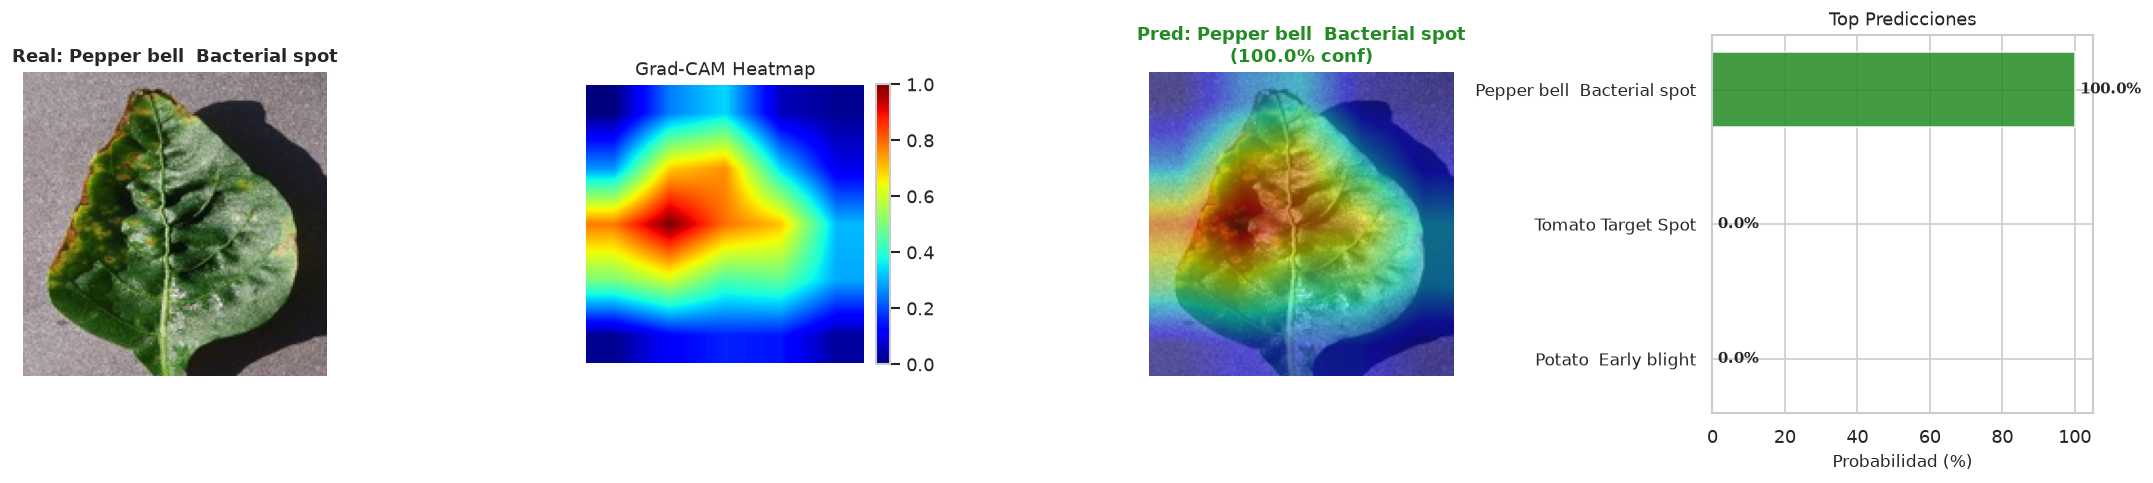

In [5]:
def plot_gradcam_diagnostic(relpath, true_label_idx, target_class=None, top_k=3):
    img_path = DATA_DIR / relpath
    img_pil = Image.open(img_path).convert("RGB")
    x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
    
    cam, probs, pred_idx = gradcam.generate_cam(x, class_idx=target_class)
    img_np, heat_np, overlay_np = GradCAM.overlay_cam(img_pil, cam, alpha=0.5, colormap="jet")
    
    true_label = short_classes[true_label_idx]
    pred_label = short_classes[pred_idx]
    confidence = probs[pred_idx] * 100.0
    is_correct = (pred_idx == true_label_idx)
    
    fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), gridspec_kw={"width_ratios": [1, 1, 1, 1.25]})
    
    # 1. Imagen Original
    axes[0].imshow(img_np)
    axes[0].set_title(f"Real: {true_label}", fontsize=11, fontweight="bold")
    axes[0].axis("off")
    
    # 2. Mapa de Calor
    im1 = axes[1].imshow(cam, cmap="jet", vmin=0, vmax=1)
    axes[1].set_title("Grad-CAM Heatmap", fontsize=11)
    axes[1].axis("off")
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)
    
    # 3. Superposición (Overlay)
    axes[2].imshow(overlay_np)
    title_color = "forestgreen" if is_correct else "crimson"
    axes[2].set_title(f"Pred: {pred_label}\n({confidence:.1f}% conf)", fontsize=11, color=title_color, fontweight="bold")
    axes[2].axis("off")
    
    # 4. Distribución de Probabilidades
    top_indices = np.argsort(probs)[-top_k:][::-1]
    top_probs = probs[top_indices] * 100.0
    top_labels = [short_classes[i] for i in top_indices]
    
    colors = ["forestgreen" if idx == true_label_idx else ("crimson" if idx == pred_idx else "steelblue") for idx in top_indices]
    y_pos = np.arange(len(top_labels))
    axes[3].barh(y_pos, top_probs, color=colors, alpha=0.85, height=0.55)
    axes[3].set_yticks(y_pos)
    axes[3].set_yticklabels(top_labels, fontsize=10)
    axes[3].invert_yaxis()
    axes[3].set_xlabel("Probabilidad (%)", fontsize=10)
    axes[3].set_xlim(0, 105)
    for i, p in enumerate(top_probs):
        axes[3].text(p + 1.5, i, f"{p:.1f}%", va="center", fontsize=9, fontweight="bold")
    axes[3].set_title("Top Predicciones", fontsize=11)
    
    plt.tight_layout()
    plt.show()

# Verificamos con la primera muestra de test
test_df = df[df.split == "test"].reset_index(drop=True)
sample_row = test_df.iloc[0]
plot_gradcam_diagnostic(sample_row["relpath"], sample_row["y"])


## 5. Casos de Estudio en el Conjunto de Test

Seleccionamos casos representativos para evaluar diferentes tipos de sintomatología vegetal:
1. **Lesiones Fúngicas / Bacterianas Localizadas:** (*Early blight*, *Bacterial spot*, *Septoria leaf spot*) → Verificamos si la activación se concentra en las manchas necróticas y anillos.
2. **Infecciones Sistémicas / Virales:** (*Tomato Yellow Leaf Curl Virus*, *Tomato Mosaic Virus*) → Observamos si atiende a la deformación foliar, rizado marginal y moteado.


Visualizando casos de estudio seleccionados:


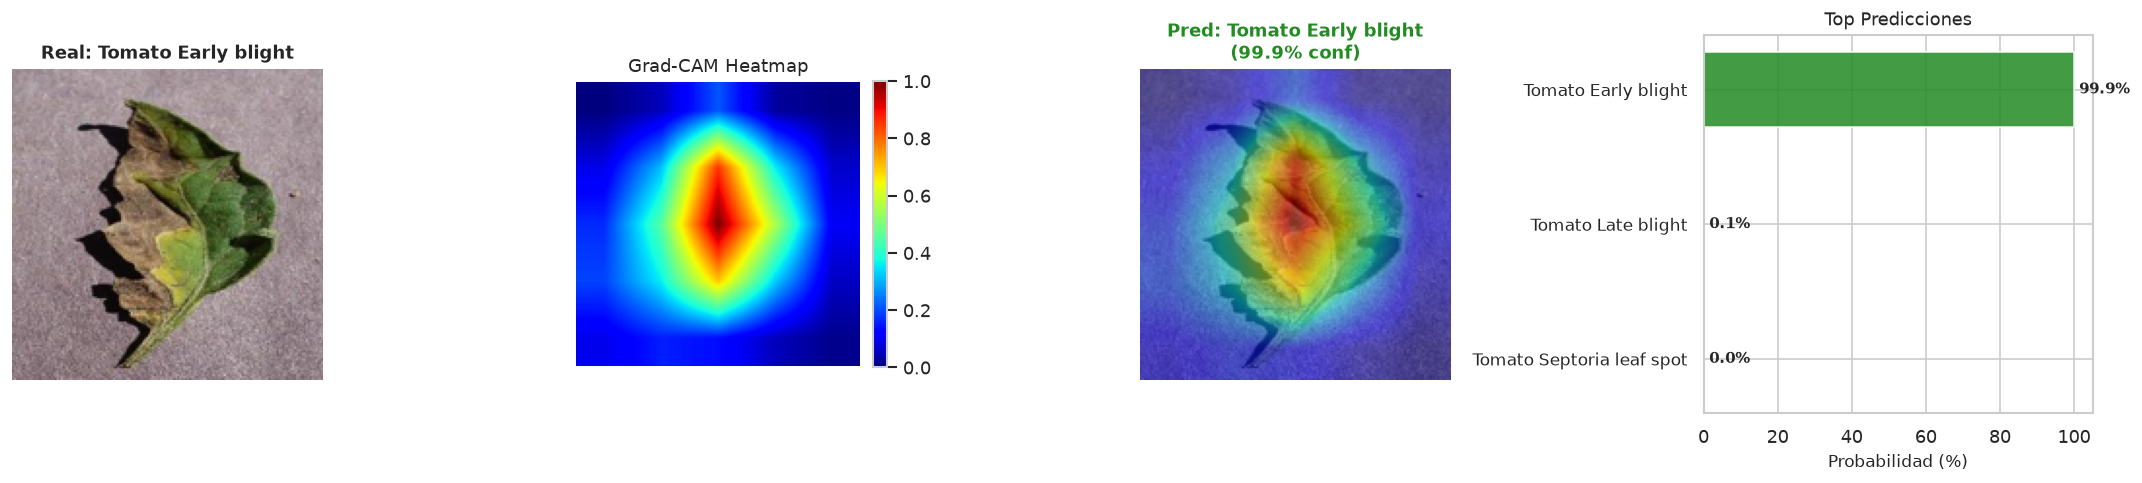

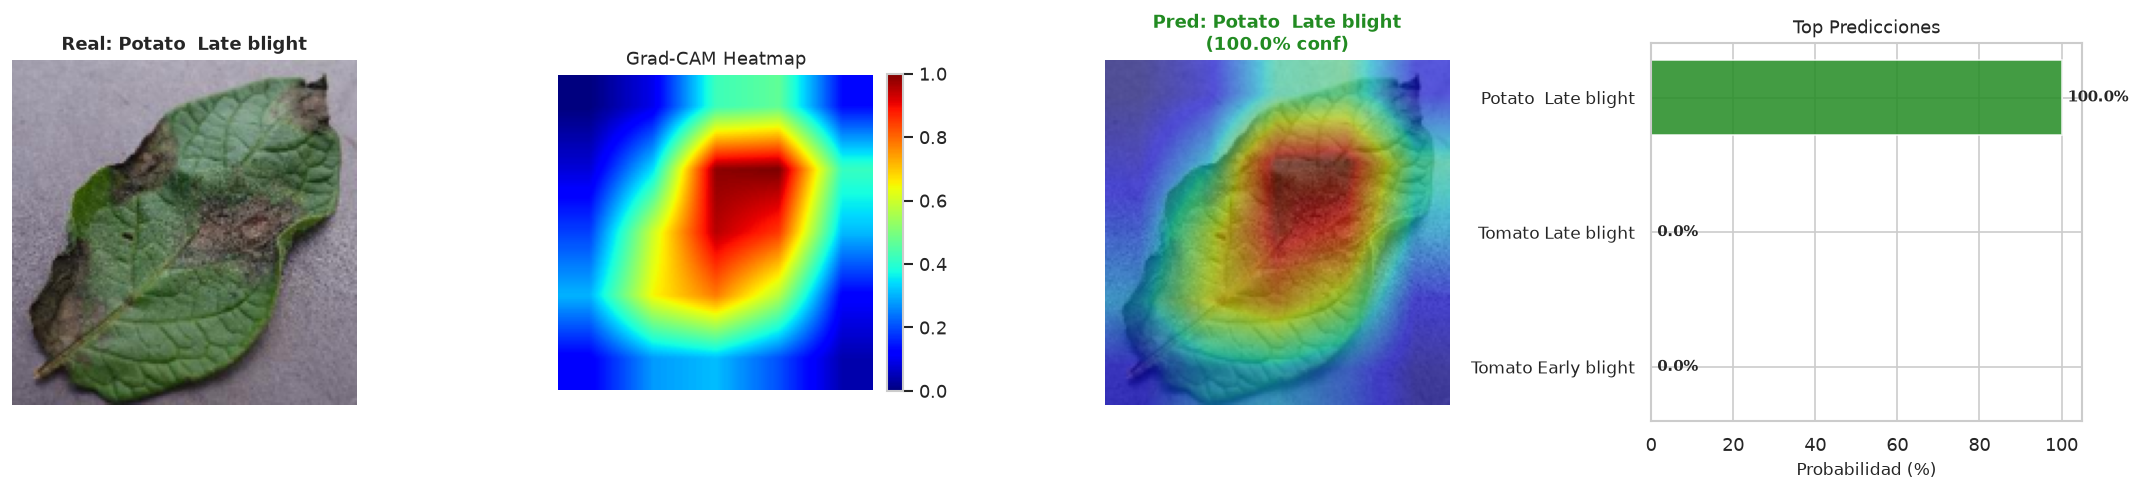

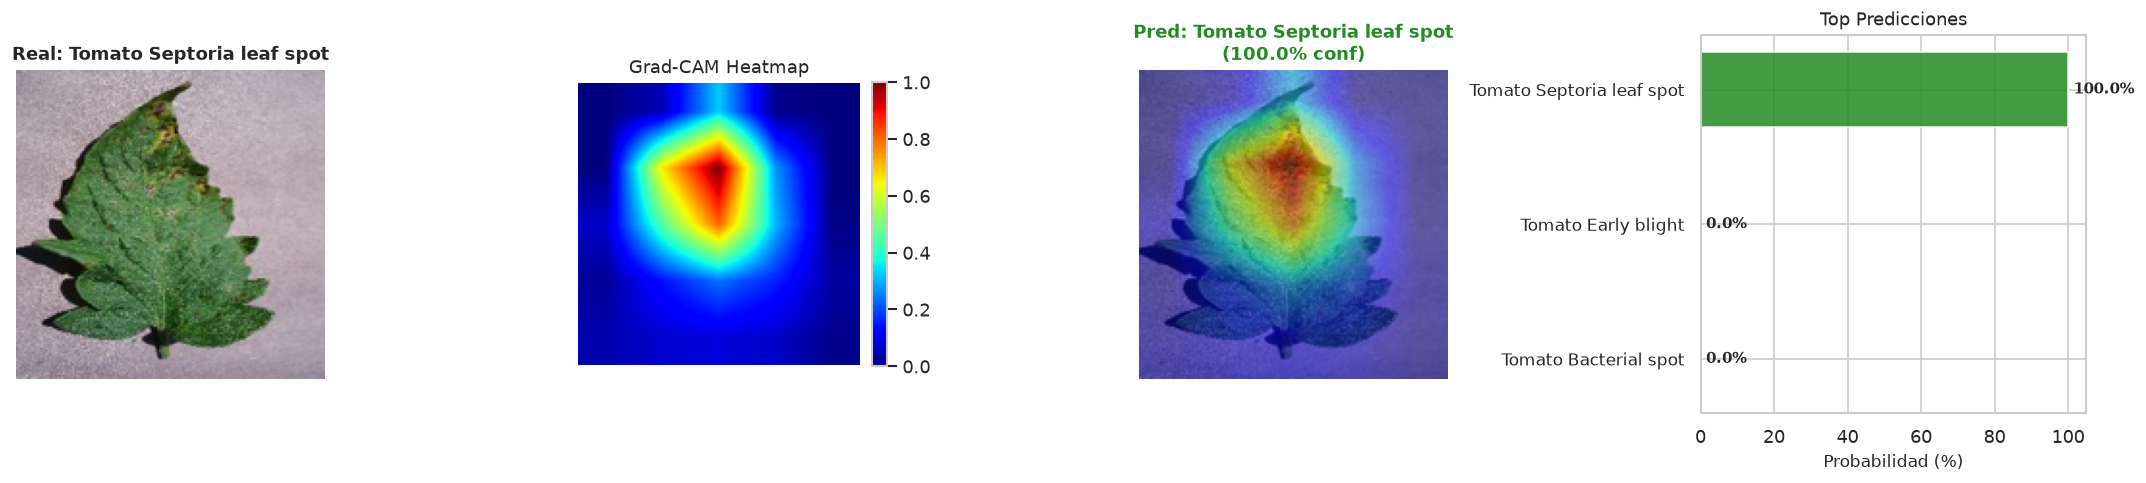

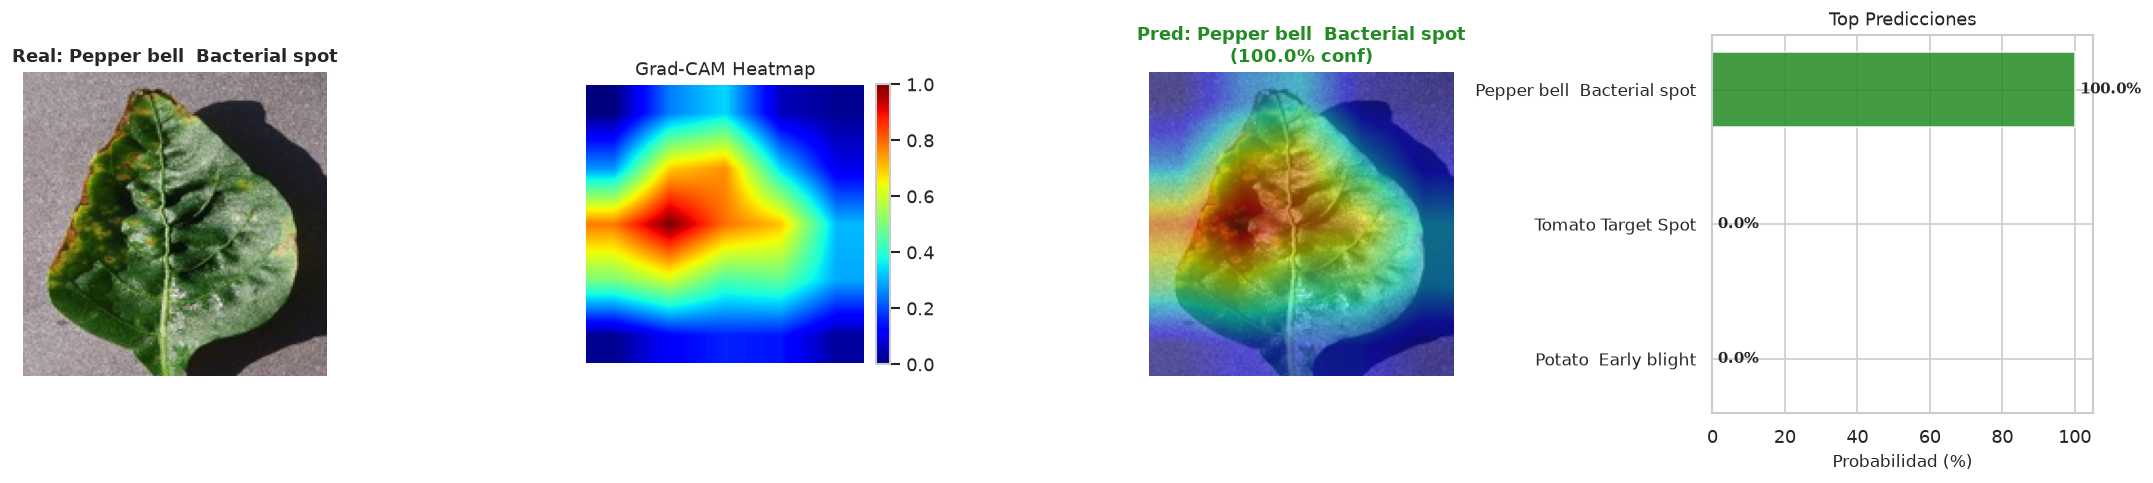

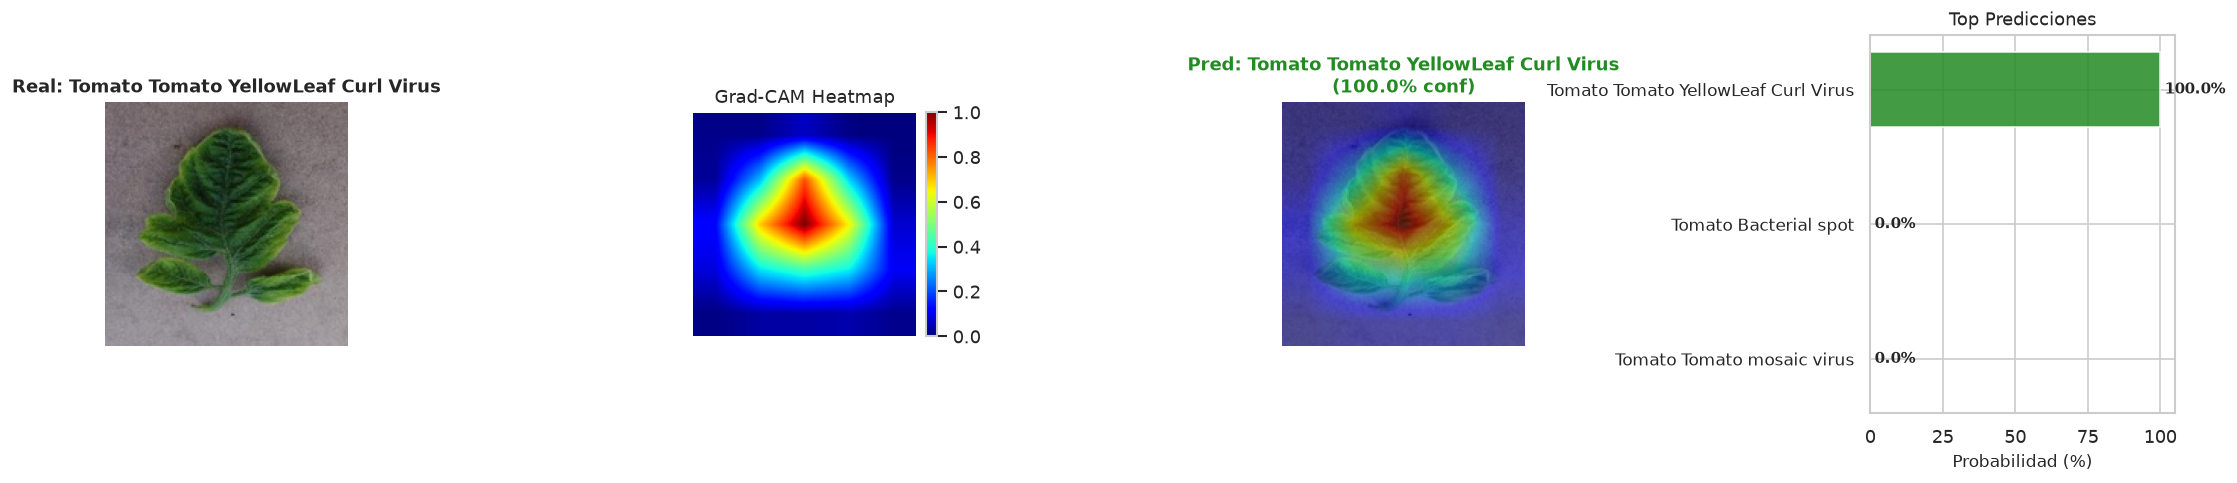

In [6]:
case_classes = [
    "Tomato_Early_blight",
    "Potato___Late_blight",
    "Tomato_Septoria_leaf_spot",
    "Pepper__bell___Bacterial_spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
]

print("Visualizando casos de estudio seleccionados:")
for cls_name in case_classes:
    cls_idx = classes.index(cls_name)
    candidates = test_df[test_df.y == cls_idx]
    if len(candidates) > 0:
        row = candidates.iloc[0]
        plot_gradcam_diagnostic(row["relpath"], row["y"])


## 6. Galería Comparativa Multiclase (Grid de Explicabilidad)

Presentamos una cuadrícula de 8 muestras aleatorias del conjunto de test que cubren diversas clases, excluyendo hojas sanas.


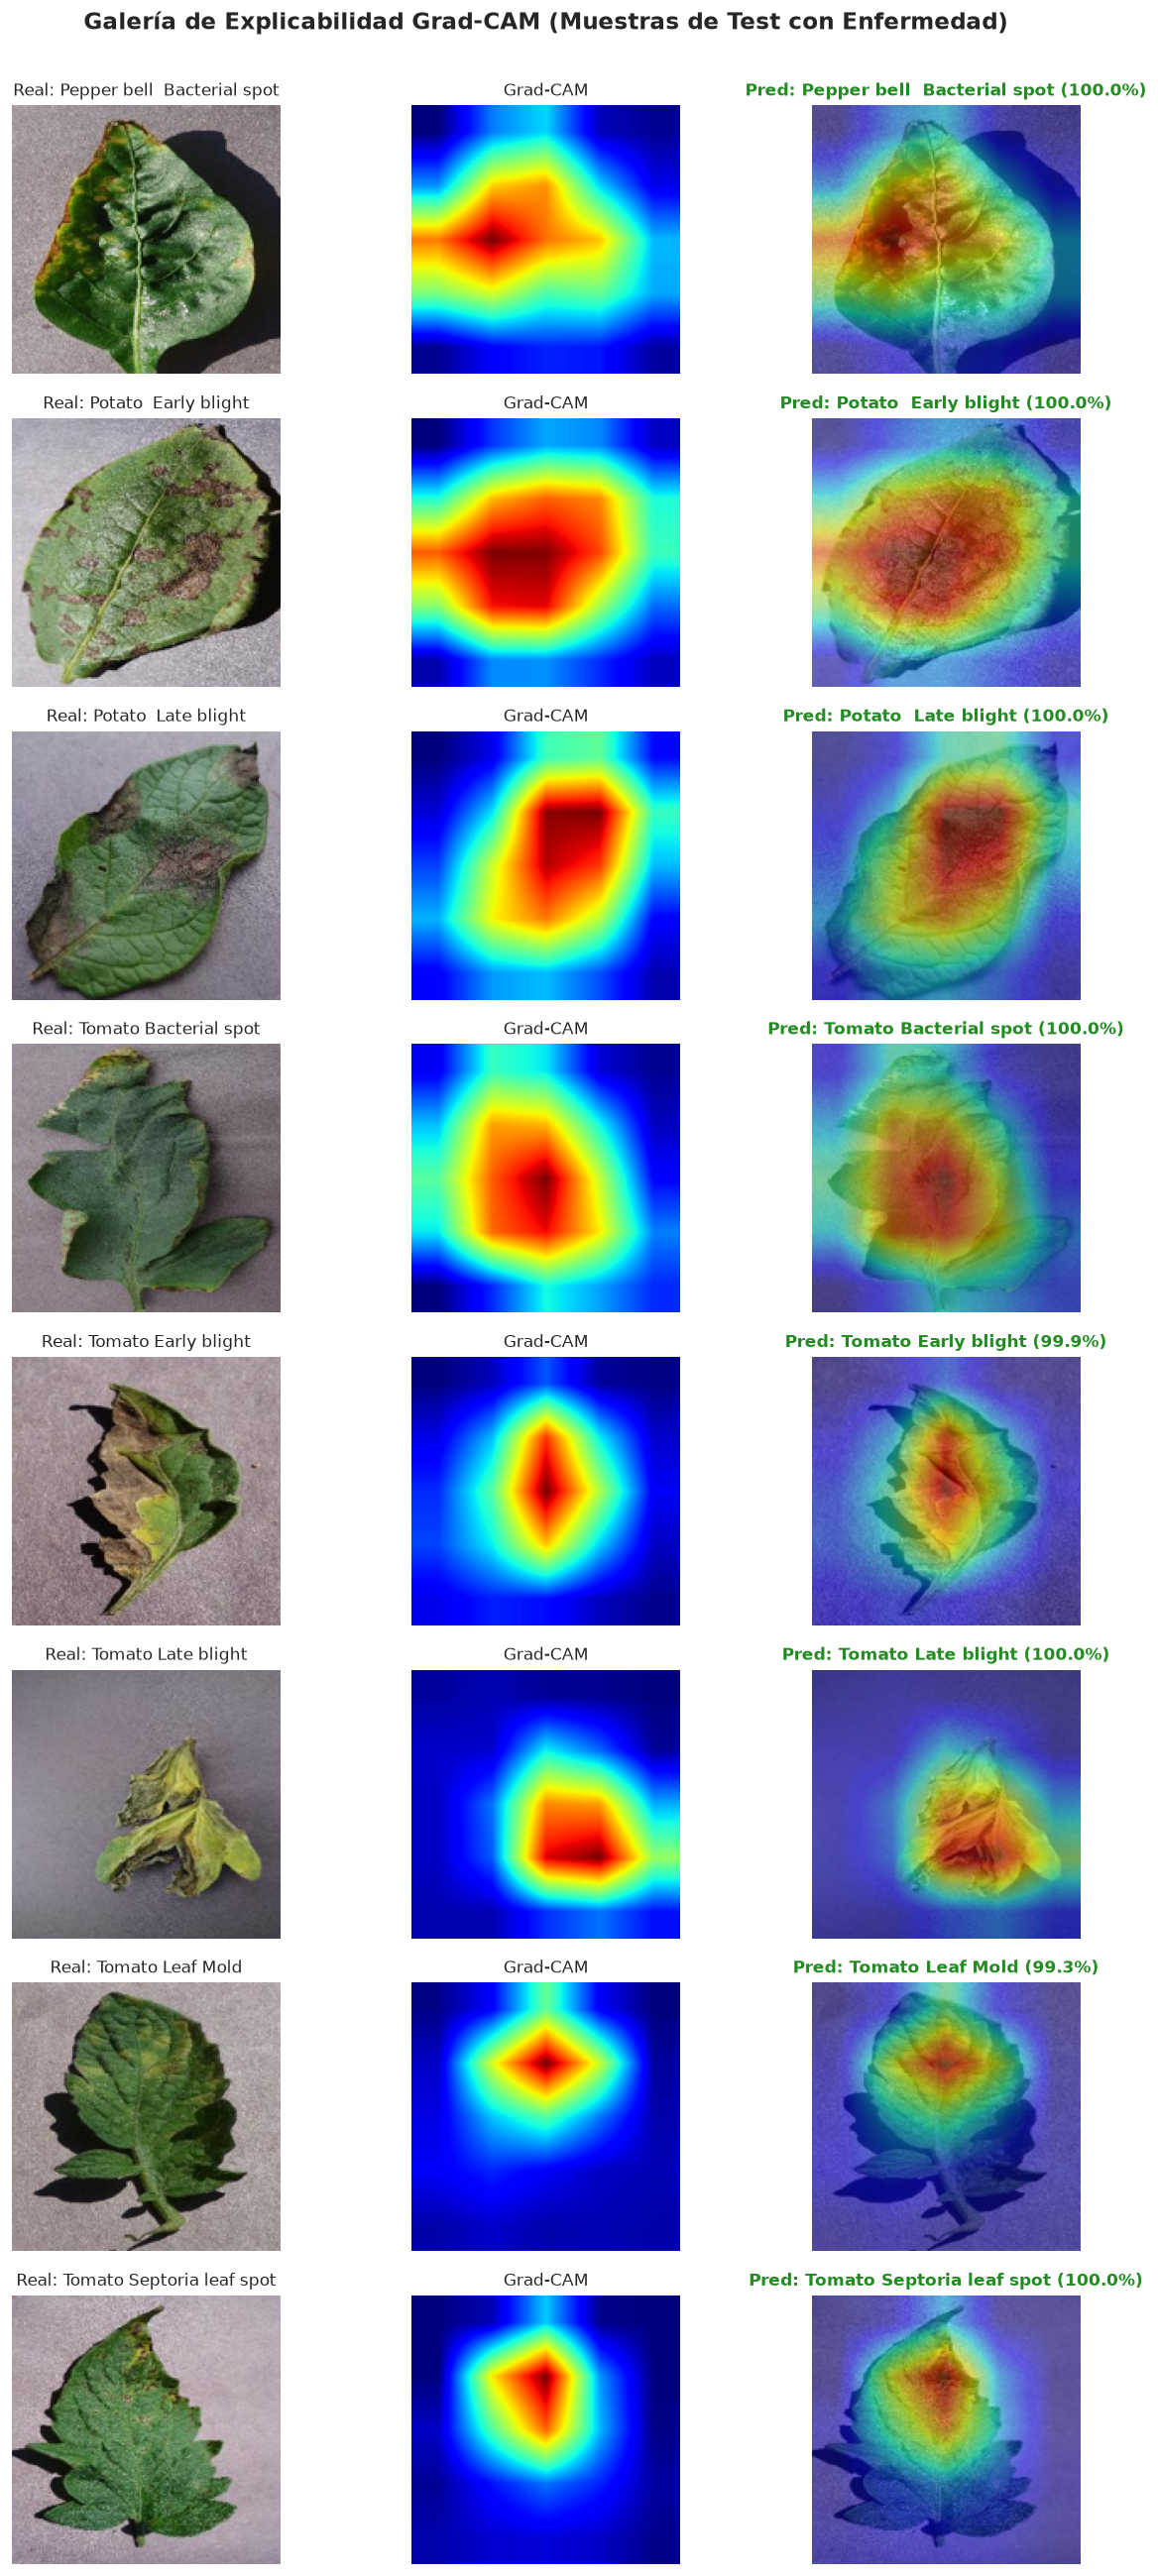

In [7]:
# Seleccionar 8 imágenes de distintas clases con enfermedad (excluyendo 'healthy')
disease_classes = [i for i, name in enumerate(classes) if "healthy" not in name.lower()][:8]
selected_rows = [test_df[test_df.y == i].iloc[0] for i in disease_classes]
selected_df = pd.DataFrame(selected_rows).reset_index(drop=True)

n_samples = len(selected_df)
fig, axes = plt.subplots(n_samples, 3, figsize=(11, 2.7 * n_samples))

for i, (_, row) in enumerate(selected_df.iterrows()):
    img_path = DATA_DIR / row["relpath"]
    img_pil = Image.open(img_path).convert("RGB")
    x = eval_tf(img_pil).unsqueeze(0).to(DEVICE)
    
    cam, probs, pred_idx = gradcam.generate_cam(x)
    img_np, heat_np, overlay_np = GradCAM.overlay_cam(img_pil, cam, alpha=0.5, colormap="jet")
    
    true_label = short_classes[row["y"]]
    pred_label = short_classes[pred_idx]
    conf = probs[pred_idx] * 100
    
    # 1. Original
    axes[i, 0].imshow(img_np)
    axes[i, 0].set_title(f"Real: {true_label}", fontsize=10)
    axes[i, 0].axis("off")
    
    # 2. Heatmap
    axes[i, 1].imshow(cam, cmap="jet", vmin=0, vmax=1)
    axes[i, 1].set_title("Grad-CAM", fontsize=10)
    axes[i, 1].axis("off")
    
    # 3. Superposición
    axes[i, 2].imshow(overlay_np)
    color = "forestgreen" if pred_idx == row["y"] else "crimson"
    axes[i, 2].set_title(f"Pred: {pred_label} ({conf:.1f}%)", fontsize=10, color=color, fontweight="bold")
    axes[i, 2].axis("off")

plt.suptitle("Galería de Explicabilidad Grad-CAM (Muestras de Test con Enfermedad)", fontsize=14, fontweight="bold", y=1.002)
plt.tight_layout()
plt.show()



## 7. Conclusiones

El uso de GradCam permite dar una explicacion a la predicción realizada por el modelo. Esto puede ser útil durante la etapa del desarrollo del mismo para validar que le de importancia a las regiones relevantes y tambien durante inferecia para darle mayor confianza al usuario final.

Tras observar el comportamiento de GradCam con nuestro modelo, vemos que en muchos casos se focaliza en las partes que permiten identificar correctamente la clase.